## Import Libraries

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from sklearn.metrics import accuracy_score

plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor":  (0.12, 0.12, 0.12, 1),
    "axes.facecolor": (0.12, 0.12, 0.12, 1),
})

## Data

dimensions de X: (100, 2)
dimensions de y: (100, 1)


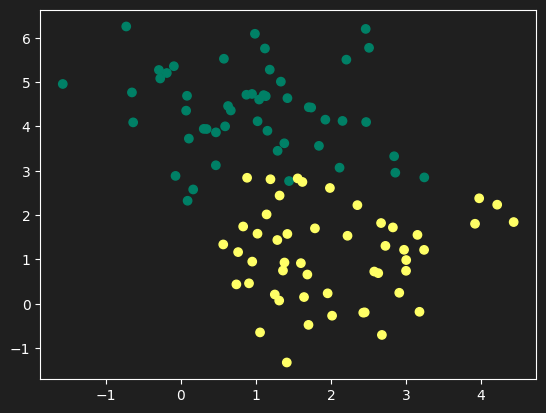

In [147]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((y.shape[0], 1))

print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer')
plt.show()

# Functions

In [148]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

def model(X, W, b):
    Z = X.dot(W) + b
    A = 1 / (1 + np.exp(-Z))
    return A 



def log_loss(A, y):
    epsilon = 1e-15
    return 1 / len(y) * np.sum(-y * np.log(A ) - (1 - y) * np.log(1 - A ))

def gradients(A, X, y): 
    dW = 1 / len(y) * np.dot( X.T, A - y) 
    db = 1 / len(y) * np.sum(A - y) 
    return (dW, db)
def update(dW, db, W, b, learning_rate): 
    W = W - learning_rate * dW
    b = b - learning_rate * db 
    return(W, b)

def predict(X, W, b): 
    A = model(X, W, b)
    print(A)
    return A >= 0.5 


### Artificial Neuron Function From Scratch

In [149]:
def artificial_neuron(X, y, learning_rate = 0.1, n_iter = 10000):
    
    #Initialisation 
    W, b = initialisation(X) 
    Loss = []

    for i in range(n_iter):
        A = model(X, W, b) 
        Loss.append(log_loss(A, y))
        dW, db = gradients(A, X, y)
        W, b = update(dW, db, W, b, learning_rate)
    
    y_pred = predict(X, W, b) 
    
    print(accuracy_score(y, y_pred))
    

    plt.plot(Loss)
    
    return (W, b)
  

[[9.62742574e-01]
 [9.99397238e-01]
 [7.85474169e-05]
 [5.99672357e-01]
 [9.98000684e-01]
 [4.21513006e-01]
 [5.03994899e-03]
 [9.30958095e-01]
 [5.76915086e-03]
 [9.99797345e-01]
 [1.19696101e-03]
 [9.99252994e-01]
 [9.61650140e-05]
 [1.22213417e-03]
 [9.73990002e-01]
 [9.91473715e-01]
 [9.99984159e-01]
 [5.91259998e-03]
 [9.99384751e-01]
 [9.85707055e-01]
 [7.51774302e-04]
 [1.73570732e-03]
 [6.78576758e-01]
 [5.38881326e-05]
 [9.99452836e-01]
 [5.72904291e-04]
 [9.99878787e-01]
 [5.04758537e-06]
 [1.04839415e-03]
 [8.94859562e-01]
 [9.99976534e-01]
 [9.27250649e-04]
 [9.96759889e-01]
 [9.99976295e-01]
 [4.66278815e-01]
 [9.81043254e-03]
 [9.97680680e-01]
 [6.37604538e-01]
 [2.77863613e-01]
 [9.84311905e-01]
 [1.60724878e-01]
 [3.88411472e-05]
 [9.88260550e-07]
 [3.46043582e-02]
 [2.85359330e-01]
 [9.88734029e-01]
 [9.99976165e-01]
 [9.99985956e-01]
 [1.86906433e-04]
 [2.79969965e-05]
 [9.99856055e-01]
 [9.92330014e-01]
 [8.52298737e-06]
 [2.70404783e-04]
 [6.23887867e-01]
 [6.799921

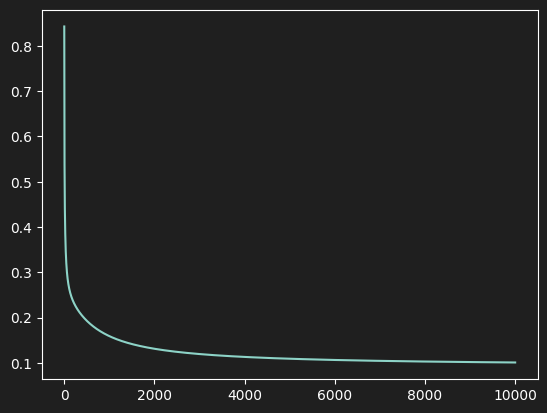

In [150]:
W, b = artificial_neuron(X, y)

## Application to new data

In [151]:
new_data = np.array([2, 1])

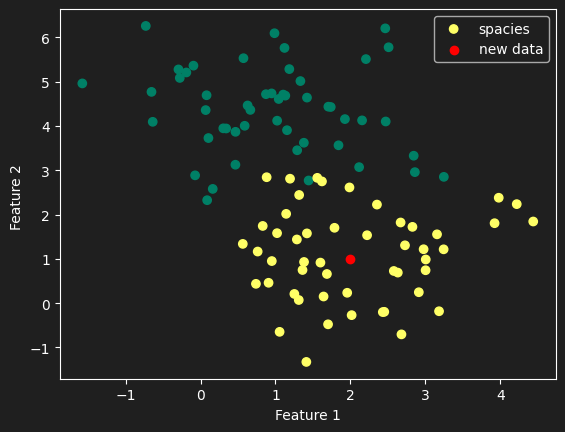

In [152]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer', label='spacies')
plt.scatter(new_data[0], new_data[1], c='r', label = 'new data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2 ')
plt.legend()

In [153]:
predict(new_data, W, b)

[0.99797136]


array([ True])

Here, our model has been trained and we want to apply it to new data. As we can see, the output probability of our activation function is 0.99, so we can deduce that our new data point belongs to class 1.

## Decision Frontier

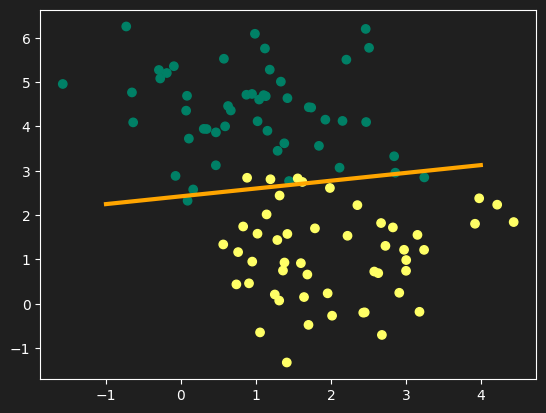

In [154]:
x0 = np.linspace(-1, 4, 100)
x1 = (-W[0] * x0 - b) / W[1]
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer')
plt.plot(x0, x1, c='orange', lw=3)

In [155]:
import plotly.graph_objects as go

In [156]:
fig = go.Figure(data=[go.Scatter3d(
    x=X[:,0].flatten(),
    y=X[:,1].flatten(), 
    z=y.flatten(), 
    mode='markers', 
    marker=dict(
        size=5, 
        color=y.flatten(), 
        colorscale='YlGn', 
        opacity=0.8,
        reversescale=True
    )
            
                     

)])

fig.update_layout(template='plotly_dark', margin=dict(l=0, r=0, b=0, t=0))
fig.layout.scene.camera.projection.type='orthographic'
fig.show()

3D visualization of the dataset using Plotly. X[:,0] and X[:,1] are the two features mapped on the x and y axes, while y (the class label) is mapped on the z axis and used as the color scale. The orthographic projection gives a clearer view of the class separation.



In [157]:
X0 = np.linspace(X[:,0].min(), X[:,0].max(), 100)
X1 = np.linspace(X[:,1].min(), X[:,1].max(), 100)
xx0, xx1 = np.meshgrid(X0, X1)
Z = W[0] * xx0 + W[1] * xx1 + b 
A = 1 / (1 + np.exp(-Z)) 

fig = (go.Figure(data=[go.Surface(z=A, x=xx0, y=xx1, colorscale='YlGn', opacity = 0.7, reversescale=True)]))

fig.add_scatter3d(x = X[:,0].flatten(), y = X[:,1].flatten(), z=y.flatten(), mode='markers', 
                  marker = dict(size=5, color=y.flatten(), colorscale='YlGn', opacity=0.9, reversescale=True))
fig.update_layout(template= 'plotly_dark', margin=dict(l=0, r=0, b=0, t=0))
fig.layout.scene.camera.projection.type = 'orthographic'
fig.show()

Here we create a 3D surface plot of the sigmoid output A over a grid spanning the range of both features. The surface represents the decision boundary of our model, values above 0.5 belong to class 1, below to class 0. The original data points are overlaid as a scatter plot to visualize how well the model separates the two classes.

## Sigmoid function

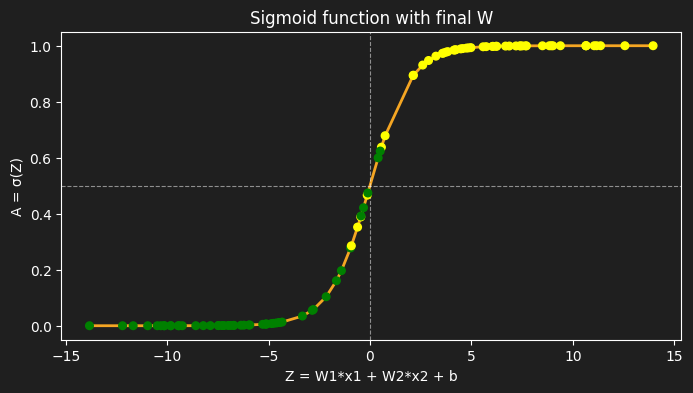

In [158]:
Z_data = (X.dot(W) + b).flatten()
Z_sorted = np.sort(Z_data)
A_curve = 1 / (1 + np.exp(-Z_sorted))
A_data = 1 / (1 + np.exp(-Z_data))

colors = np.where(y.flatten() == 1, 'yellow', 'green')

plt.figure(figsize=(8, 4))
plt.plot(Z_sorted, A_curve, color='#f5a623', linewidth=2)
plt.axvline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
plt.scatter(Z_data, A_data, c=colors, zorder=5, s=30)
plt.title('Sigmoid function with final W', color='white')
plt.xlabel('Z = W1*x1 + W2*x2 + b', color='white')
plt.ylabel('A = σ(Z)', color='white')
plt.ylim(-0.05, 1.05)
plt.show()

In [159]:
from utilities import *

In [160]:
X_train, y_train, X_test, y_test = load_data()

In [161]:
X_train.shape

(1000, 64, 64)

In [162]:
X_train =  X_train.reshape(X_train.shape[0], -1)


In [163]:
X_test =  X_test.reshape(X_test.shape[0], -1)

In [164]:
print(X_train.shape, X_test.shape)

(1000, 4096) (200, 4096)


So now we have two dimensions.

In [165]:
np.unique(y_train, return_counts=True)

(array([0., 1.]), array([500, 500]))

In [166]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

def model(X, W, b):
    Z = X.dot(W) + b
    A = 1 / (1 + np.exp(-Z))
    return A 



def log_loss(A, y):
    epsilon = 1e-15
    return 1 / len(y) * np.sum(-y * np.log(A + epsilon ) - (1 - y) * np.log(1 - A + epsilon))

def gradients(A, X, y): 
    dW = 1 / len(y) * np.dot( X.T, A - y) 
    db = 1 / len(y) * np.sum(A - y) 
    return (dW, db)
def update(dW, db, W, b, learning_rate): 
    W = W - learning_rate * dW
    b = b - learning_rate * db 
    return(W, b)

def predict(X, W, b): 
    A = model(X, W, b)
    #print(A)
    return A >= 0.5 


In [167]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [168]:
X_train_reduced = scaler.fit_transform(X_train)

In [169]:
X_test_reduced = scaler.transform(X_test)

In [170]:
def artificial_neuron(X, y, learning_rate = 0.01, n_iter = 10000):
    
    #Initialisation 
    W, b = initialisation(X) 
    Loss = []

    for i in range(n_iter):
        A = model(X, W, b) 
        Loss.append(log_loss(A, y))
        dW, db = gradients(A, X, y)
        W, b = update(dW, db, W, b, learning_rate)
    
    y_pred = predict(X, W, b) 
    
    print(accuracy_score(y, y_pred))
    

    plt.plot(Loss)
    
    return (W, b)
  

0.735


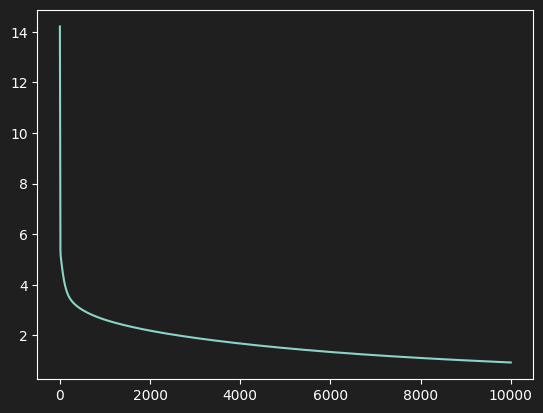

In [171]:
W, b = artificial_neuron(X_train_reduced, y_train)

Our model did not converge so we can continue the learning.

In [172]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = predict(X_test_reduced, W, b)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.49      0.49      0.49       100
         1.0       0.50      0.50      0.50       100

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.49      0.49      0.49       200

[[49 51]
 [50 50]]


As we can see, the f1-score is quiet low, our model is equivalent to the randomness on the test set.

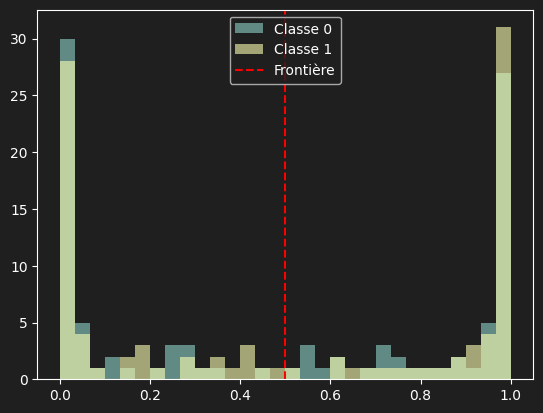

In [177]:
A = model(X_test_reduced, W, b)
plt.hist(A[y_test == 0], bins=30, alpha=0.6, label='Classe 0')
plt.hist(A[y_test == 1], bins=30, alpha=0.6, label='Classe 1')
plt.axvline(0.5, color='red', linestyle='--', label='Frontière')
plt.legend()
plt.show()

Our model did not split the two classes.